# Titanic Dataset – Mini Visualization Dashboard
### Data Science Internship – Task 4

This notebook presents a mini dashboard analyzing Titanic passenger data
through data cleaning, feature engineering, and multiple visualizations
to uncover key survival insights.

## Import Libraries

We import the required libraries for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()


## Load Dataset

The Titanic dataset is loaded into pandas for analysis.

In [5]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data Cleaning

Missing values are handled to improve dataset quality:
- Age filled with median
- Embarked filled with mode
- Cabin dropped due to excessive missing values

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"], errors="ignore")

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Observation

Missing values in key columns have been successfully handled,
making the dataset cleaner and more suitable for visualization.

## Feature Engineering

New features are created to improve analysis:
- FamilySize = SibSp + Parch
- AgeGroup categorization

In [10]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=["Child","Teen","YoungAdult","Adult","Senior"]
)

## Age Distribution of Passengers

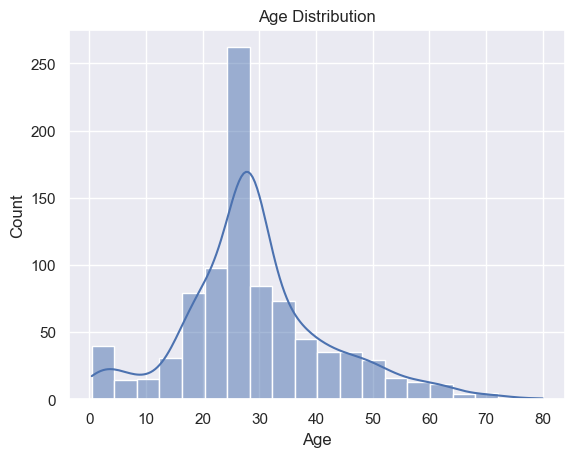

In [11]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Insight

Most passengers were between 20 and 40 years old,
with fewer elderly passengers.

## Survival Rate by Gender

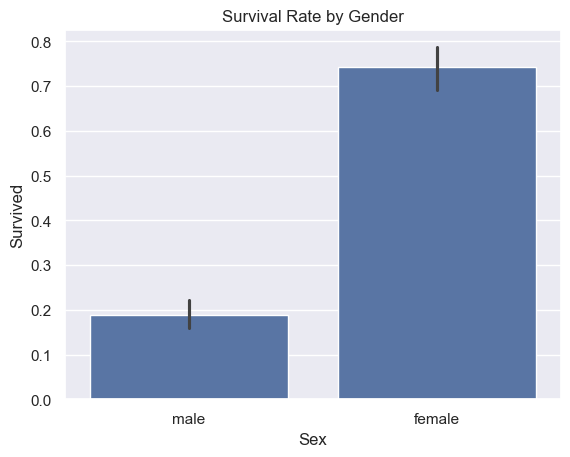

In [12]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()

### Insight

Female passengers had significantly higher survival rates
than male passengers.

## Survival Rate by Passenger Class

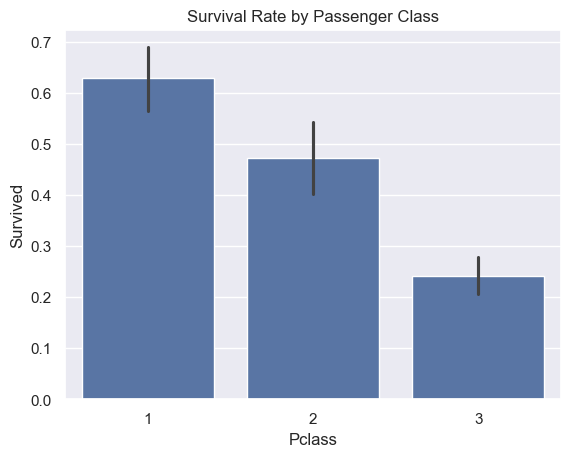

In [13]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

### Insight

First-class passengers had the highest survival probability,
while third-class passengers had the lowest.

## Fare Distribution by Passenger Class

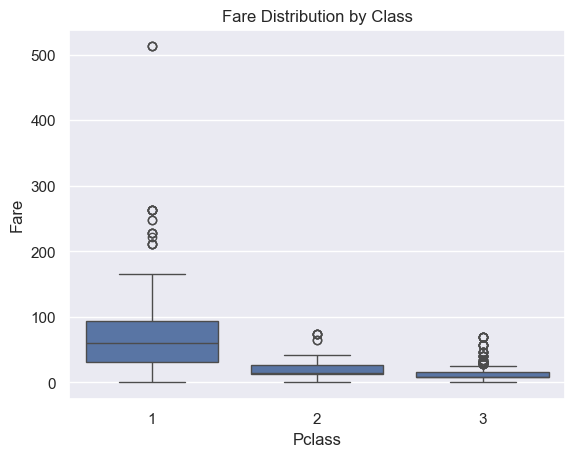

In [14]:
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare Distribution by Class")
plt.show()

### Insight

Higher passenger classes generally paid higher fares,
with first-class fares showing the widest range.

## Age vs Fare (Colored by Survival)

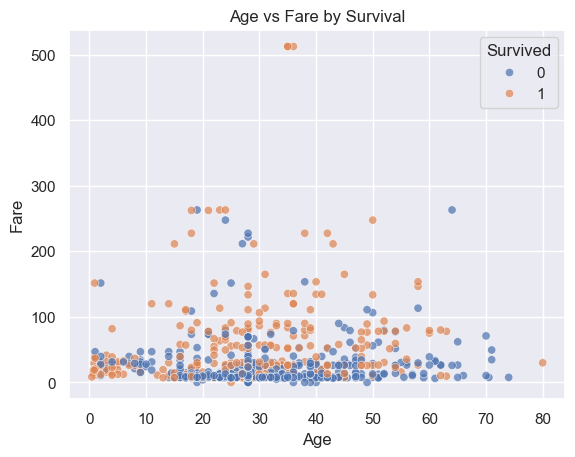

In [15]:
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, alpha=0.7)
plt.title("Age vs Fare by Survival")
plt.show()

### Insight

Passengers paying higher fares generally had better survival
rates, suggesting socioeconomic factors influenced outcomes.

## Correlation Heatmap

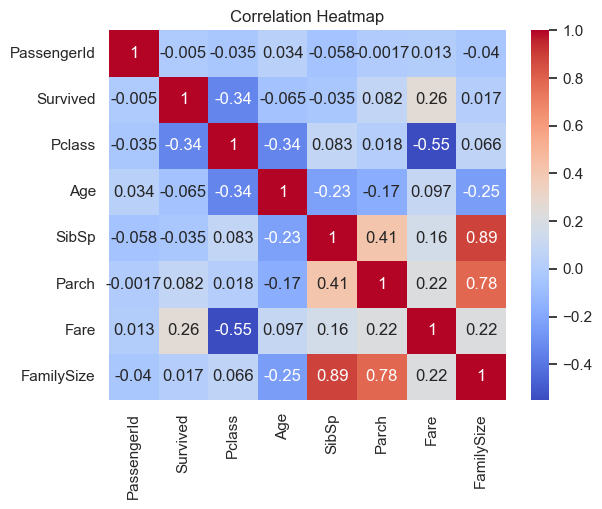

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight

Passenger class, fare, and family size all show measurable
relationships with survival outcomes.

## Conclusion

This dashboard demonstrates how data cleaning, feature engineering,
and visualization techniques can be used to communicate important
patterns in the Titanic dataset.

Key findings:
- Gender strongly influenced survival
- Passenger class significantly affected outcomes
- Fare and socioeconomic status played important roles
- Family size and age also contributed to survival patterns

This project strengthens practical skills in data storytelling,
visual analytics, and exploratory data analysis.